In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib notebook

In [2]:
SURVEY_FILE = './survey_info.csv'

from matplotlib.lines import Line2D

def plot_map(df, labels, label_names=None, show_label=True, show_legend=False, color_scheme='brg'):
    unique_labels = list(set(labels))
    unique_labels.sort()
    print("Unique labels:", len(unique_labels))
    colors = dict([(l,i) for i, l in enumerate(unique_labels)])
    point_color = [colors[l] for l in labels]

    plt.figure()
    plt.scatter(df.long, df.lat, c=point_color, cmap=color_scheme, alpha=0.6)
    
    if label_names is None:
        label_names = labels
    
    if show_label:
        for long, lat, label in zip(df.long, df.lat, label_names):
            plt.annotate(label, (long,lat), 
                textcoords="offset points",
                xytext=(0,10),
                ha='center') 
            
    if show_legend:
        legend_elements = []
        n = len(unique_labels)-1
        cmap = plt.get_cmap(color_scheme)
        for i,l in enumerate(unique_labels):
            legend_elements.append(Line2D([0], [0], color='w', label=l, 
                                          marker='o', markerfacecolor=cmap(i/n), markersize=8))
        plt.legend(handles=legend_elements, loc='best')
    
    plt.grid(True)
    plt.show()

In [3]:
df = pd.read_csv(SURVEY_FILE, sep='\t')
df.set_index('survey', drop=False, inplace=True)
#display(df.head())

In [ ]:
plot_map(df, df.area)

---

### Mantendo somente surveys que contém dt=4000

In [4]:
s4000 = ['b-01-75-at', 'b-01-80-at', 'b-01-81-at', 'b-01-82-at', 'b-01-83-at', 'b-01-84-at', 'b-01-88-at', 'b-02-77-at', 'b-02-79-at', 'b-02-80-at', 'b-02-81-ar', 'b-02-82-at', 'b-02-84-at', 'b-03-75-at', 'b-03-80-ar', 'b-03-81-at', 'b-03-82-at', 'b-04-80-at', 'b-04-81-at', 'b-04-82-at', 'b-04-83-at', 'b-05-81-at', 'b-05-83-at', 'b-06-76-at', 'b-06-79-at', 'b-06-82-at', 'b-07-76-at', 'b-07-78-ak', 'b-07-81-at', 'b-07-83-at', 'b-08-75-at', 'b-08-78-at', 'b-08-83-at', 'b-09-75-at', 'b-09-81-at', 'b-10-80-at', 'b-10-81-at', 'b-10-82-at', 'b-11-77-at', 'b-11-78-at', 'b-11-82-at', 'b-11-88-at', 'b-12-77-at', 'b-13-76-at', 'b-13-78-at', 'b-15-77-ak', 'b-15-79-at', 'b-15-87-ar', 'b-16-76-at', 'b-16-77-at', 'b-17-77-at', 'b-23-81-ar', 'b-25-77-ak', 'b-28-75-at', 'b-29-76-at', 'b-30-82-ar', 'b-32-84-ar', 'b-33-77-ak', 'b-59-82-ar', 'b-60-82-ar', 'h-14-79-sc', 'h-17-79-sc', 'h-18-79-sc', 'j-1-88-sc', 'l-09-11-ga-mcs', 'l-11-11-bs-mcs', 'l-12-82-wg', 'l-4-90-sc', 'w-1-70-sc', 'w-1-79-cb', 'w-10-78-sc', 'w-10-79-bs', 'w-12-79-eg', 'w-13-77-sc', 'w-13-79-ar', 'w-14-76-sf', 'w-14-79-wg', 'w-16-76-sf', 'w-16-77-bs', 'w-17-77-ar', 'w-17-79-nc', 'w-18-75-np', 'w-18-77-ar', 'w-19-78-ar', 'w-2-70-sc', 'w-2-75-wg', 'w-20-79-ar', 'w-21-80-bs', 'w-22-79-np', 'w-23-81-sc', 'w-25-80-ar', 'w-26-80-wg', 'w-26-80-wo', 'w-27-81-cs', 'w-29-80-wo', 'w-3-75-sc', 'w-3-79-cb', 'w-30-81-cs', 'w-30-81-sc', 'w-31-81-bs', 'w-31-81-sc', 'w-32-82-cc', 'w-33-81-ar', 'w-33-82-sc', 'w-34-82-aa', 'w-34-82-mb', 'w-35-82-nc', 'w-36-83-sc', 'w-37-84-sc', 'w-38-83-sc', 'w-39-85-wo', 'w-4-74-sc', 'w-4-77-sa', 'w-4-82-nc', 'w-40-80-ak', 'w-40-85-sc', 'w-5-75-sc', 'w-5-77-ar', 'w-5-82-sc', 'w-50-70-cs', 'w-6-75-nc', 'w-6-78-bs', 'w-6-85-sc', 'w-62-77-ar', 'w-67-82-wg', 'w-8-78-ar', 'w-9-78-nc', 'w-9-79-ar', 'w-95-92-sa']

df4000 = df.loc[df.survey.isin(s4000)]

Unique labels: 9


<IPython.core.display.Javascript object>


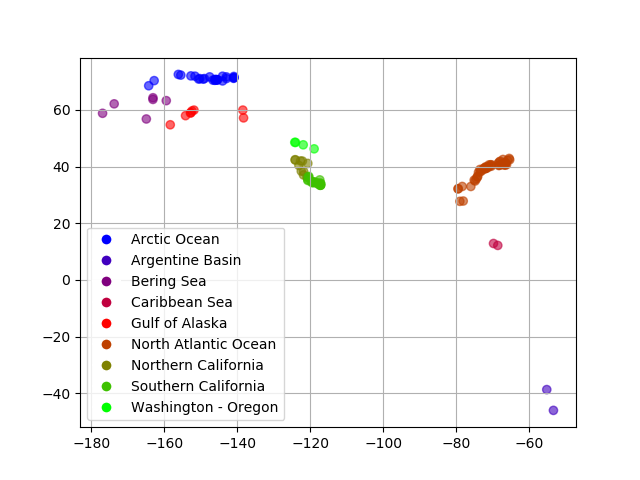

In [5]:
# Plot area

#plot_map(df4000, df4000.area)
plot_map(df4000, df4000.area, show_label=False, show_legend=True)
#plot_map(df4000, df4000.area, show_label=False)
#plot_map(df4000, df4000.area, label_names=df4000.split, show_legend=True)

Unique labels: 3


<IPython.core.display.Javascript object>


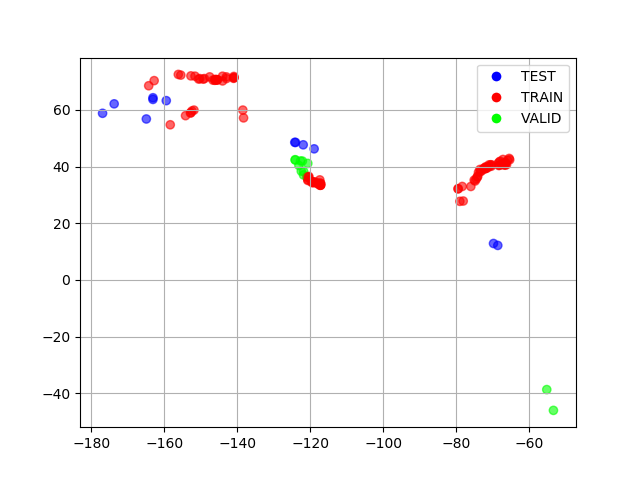

In [6]:
# Plot dataset split

plot_map(df4000, df4000.split, show_label=False, show_legend=True)
#plot_map(df4000, df4000.split, label_names=df4000.area, show_legend=True)

---

### Estatísticas de cada dataset

In [7]:
# Dataset sizes

df4000.groupby('split').size_mb.sum()

split
TEST      3081.3
TRAIN    24244.2
VALID     3096.1
Name: size_mb, dtype: float64

<IPython.core.display.Javascript object>


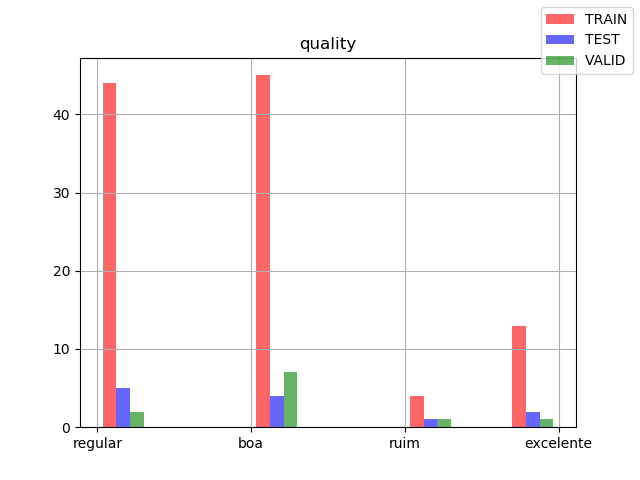

In [11]:
def plot_histogram(df, column, as_ratio=False):
    split = ['TRAIN', 'TEST', 'VALID']
    colors = ['red', 'blue', 'green']
    data = [df.loc[df.split == s, column] for s in split]

    fig, ax = plt.subplots(1,1)
    ax.hist(data, bins='auto', label=split, color=colors,
            rwidth=0.8, alpha=0.6, density=as_ratio)
    ax.set_title(column)
    ax.grid(True)
    
    fig.legend()
    #fig.tight_layout()
    fig.show()
    

as_ratio = False

#plot_histogram(df4000, 'year', as_ratio=as_ratio)
plot_histogram(df4000, 'quality', as_ratio=as_ratio)

In [12]:
df4000.groupby('migration_technique').survey.nunique()

migration_technique
Finite Difference Migration     2
Kirchhoff Time Migration       30
None                           95
Prestack Depth Migration        1
True Amp Migration              1
Name: survey, dtype: int64

<IPython.core.display.Javascript object>


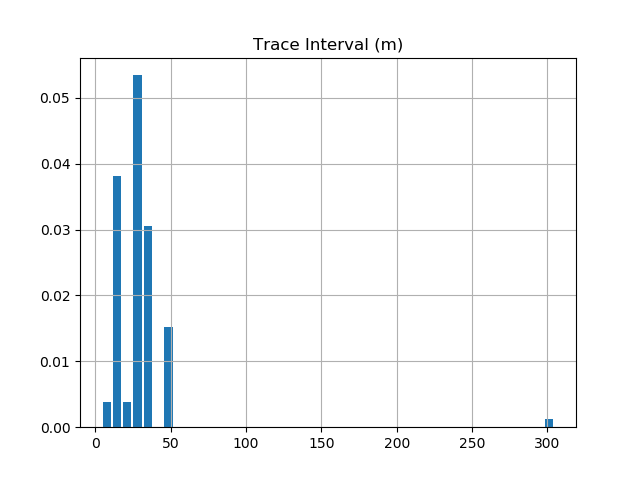

Bin size: 6.8


In [10]:
#df4000.groupby('dx').suffix.nunique()
dx = df4000.dx.values
dx = dx[dx != 'None'].astype(np.float)
dx.sort()

plt.figure()
_, bins, _ = plt.hist(dx, bins='auto', rwidth=0.8, density=True)
plt.grid(True)
plt.title("Trace Interval (m)")
plt.show()

print("Bin size: {:.1f}".format(np.median(np.diff(bins))))

In [ ]:
# Print surveys from each split to be searched at NAMSS
# Indices:
#  - TEST: 0
#  - TRAIN: 1
#  - VALID: 2

index = 0

surveys = df4000.groupby('split').survey.unique()[index]
print(' OR '.join(surveys))